In [150]:
import json
from datetime import datetime
from dateutil import parser

In [151]:
with open("posts_dict.json", "r", encoding="utf-8") as f:
    posts_dict = json.load(f)

with open("repost_with_time.json", "r", encoding="utf-8") as f:
    repost_dict_times = json.load(f)

# Load repost_dict
with open("reposts_dict.json", "r", encoding="utf-8") as f:
    repost_dict = json.load(f)

# Load followers_dict
with open("followers_dict.json", "r", encoding="utf-8") as f:
    followers = json.load(f)

In [146]:
def follower_repost_ratio(follow_map, repost_dict, posts_dict):
    total = follower = 0
    for r, uris in repost_dict.items():
        follows = set(follow_map.get(r, []))
        for u in uris:
            a = posts_dict.get(u, {}).get("author", {}).get("did")
            total += 1
            follower += a in follows
    print(f" Ratio of reposters that follow original poster: {follower / total if total else 0}")
    return follower / total if total else 0



In [136]:
def avg_reposts_per_user(repost_dict):
    counts = [len(uris) for uris in repost_dict.values() if uris]
    avg = sum(counts) / len(counts) if counts else 0
    print(f" Average #reposts per reposter: {avg:.2f}")
    return avg

In [137]:


def avg_repost_delay(repost_times_dict, posts_dict):
    """
    Compute the average delay (in seconds) between post and repost.
    Positive = repost happened after post.
    """
    diffs = []
    for reposter, uri_times in repost_times_dict.items():
        for uri, repost_time in uri_times.items():
            post_obj = posts_dict.get(uri, {})
            post_time = (
                post_obj.get("record", {}).get("createdAt")
                or post_obj.get("post", {}).get("record", {}).get("createdAt")
            )

            dt_post = parser.isoparse(post_time)
            dt_repost = parser.isoparse(repost_time)
            diffs.append((dt_repost - dt_post).total_seconds())

    avg_diff = sum(diffs) / len(diffs)
    print(f" Average repost delay: {avg_diff/3600:.2f} hours ({avg_diff:.1f} seconds)")
    return avg_diff


In [144]:
def repost_ratio(posts_dict):
    """
    Takes a dict of Bluesky posts and returns the ratio of posts
    with repostCount > 0 to the total number of posts.
    """
    if not posts_dict:
        return 0.0

    total = len(posts_dict)
    reposted = sum(1 for post in posts_dict.values() if post.get("repostCount", 0) > 0)
    print(f"ratio of posts that were reposted: {reposted/total }")
    return reposted / total



In [139]:
def avg_reposts_not_including_zeros(posts_dict):
    """
    Returns the average number of reposts per post,
    counting only posts where repostCount > 0.
    """
    repost_counts = [post.get("repostCount", 0) for post in posts_dict.values() if post.get("repostCount", 0) > 0]
    if not repost_counts:
        return 0.0
    print(f"Average #reposts per post: {sum(repost_counts) / len(repost_counts)}")
    return sum(repost_counts) / len(repost_counts)


In [140]:
def overlap_stats(posts_dict, reposts_dict):
    """
    Returns (overlap_size, num_posters, num_reposters)
    where:
      - overlap_size = number of users in both sets
      - num_posters = unique authors in posts_dict
      - num_reposters = unique keys in reposts_dict
    """
    posters = {post["author"]["did"] for post in posts_dict.values() if "author" in post}
    reposters = set(reposts_dict.keys())

    overlap = posters & reposters
    print(f"Overlap: {len(overlap)}, Reposters: {len(reposters)}, Posters: {len(posters)}")
    return len(overlap), len(posters), len(reposters)


In [152]:
avg_repost_delay(repost_dict_times,posts_dict)
follower_repost_ratio(followers,repost_dict,posts_dict)
avg_reposts_per_user(repost_dict)
repost_ratio(posts_dict)
avg_reposts_not_including_zeros(posts_dict)
overlap_stats(posts_dict,repost_dict)
print("###")



 Average repost delay: 7.33 hours (26378.4 seconds)
 Ratio of reposters that follow original poster: 0.13728137860082304
 Average #reposts per reposter: 1.81
ratio of posts that were reposted: 0.2298
Average #reposts per post: 4.3933855526544825
Overlap: 491, Reposters: 8574, Posters: 4288
###


In [88]:
print(len(repost_dict_times))

34159


In [153]:
import matplotlib.pyplot as plt
from dateutil import parser
import numpy as np

def plot_repost_delays_hours_loglog(repost_times_dict, posts_dict, bins=80):
    """
    Plot histogram of repost delays (in hours) as points on a log–log scale.
    Negative delays are shown separately on the left (absolute value ignored in log).
    """
    delays = []
    for reposter, uri_times in repost_times_dict.items():
        for uri, repost_time in uri_times.items():
            post = posts_dict.get(uri, {})
            post_time = (
                post.get("record", {}).get("createdAt")
                or post.get("post", {}).get("record", {}).get("createdAt")
            )
            if not (post_time and repost_time):
                continue
            t_post = parser.isoparse(post_time)
            t_repost = parser.isoparse(repost_time)
            delays.append((t_repost - t_post).total_seconds() / 3600)  # hours


    delays = np.array(delays)
    positive = delays[delays > 0]
    negative = np.abs(delays[delays < 0])

    pos_counts, pos_edges = np.histogram(positive, bins=bins)
    pos_centers = 0.5 * (pos_edges[:-1] + pos_edges[1:])

    neg_counts, neg_edges = np.histogram(negative, bins=bins)
    neg_centers = 0.5 * (neg_edges[:-1] + neg_edges[1:])

    plt.figure(figsize=(7, 5))
    plt.scatter(pos_centers, pos_counts, color="royalblue", s=25, label="Positive delays")
    if len(negative):
        plt.scatter(-neg_centers, neg_counts, color="tomato", s=25, label="Negative delays")

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.xscale("symlog")  # symmetric log allows ± values
    plt.yscale("log")
    plt.title("Repost Delay Distribution (hours, log–log scale, points)")
    plt.xlabel("Delay (hours)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return delays


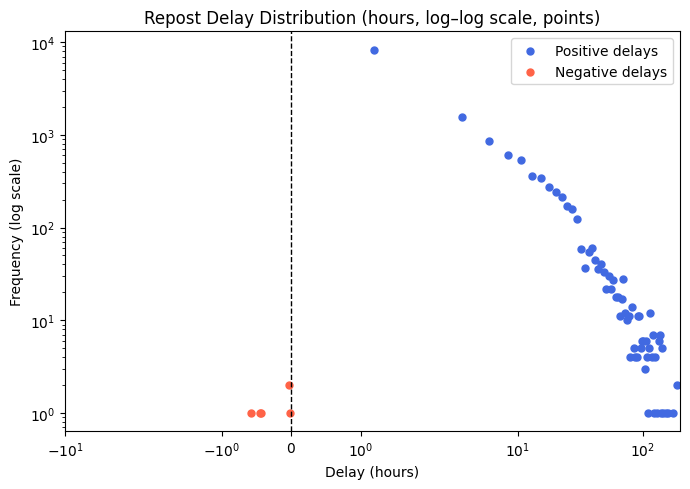

array([0.29479972, 0.00834389, 0.01002389, ..., 1.07604139, 5.87112667,
       0.50426611], shape=(14524,))

In [154]:
plot_repost_delays_hours_loglog(repost_dict_times,posts_dict)